# ML-10 — Content Action Playbook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Muhammad-Ahmed-Zia/flyrank-ml-internship/blob/main/work/notebooks/w07_action_playbook.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Ranked actions + reason codes

*The queue: what to do first, and why, in words a human trusts.*

The queue ranks content_hash_id by the client-grouped Random Forest's
predicted probability of decline (from w05/w06, Precision@50=0.740 on
the honest split — not the inflated 0.940 naive-split number). Each
row gets ONE action label and ONE reason code, matching the discipline
from ML-07's baseline.

Action labels: review_content (high decline probability, real
volume) | monitor (moderate probability or low volume) |
no_action_needed (low probability).

Reason codes, tied to what the model actually leans on (permutation
importance from w06): declining_visibility_pattern (driven primarily
by content_age_days and avg_impr_first_half, the top two features),
ctr_shortfall_at_position (secondary signal, from the ML-07 baseline
logic still present as a feature).

In [9]:
%pip install -q duckdb huggingface_hub scikit-learn
import duckdb, pandas as pd, numpy as np, json, os
from google.colab import userdata
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import average_precision_score

HF_TOKEN = userdata.get("HF_TOKEN")
con = duckdb.connect()
con.execute(f"CREATE SECRET (TYPE huggingface, TOKEN '{HF_TOKEN}')")
REL = "hf://datasets/FlyRank/internship-warehouse"
MONTH = "2026-03"

base = con.sql(f"""
    SELECT
        content_hash_id, client_hash_id,
        SUM(gsc_impressions) FILTER (WHERE report_date < DATE '{MONTH}-16') AS impressions,
        SUM(gsc_clicks) FILTER (WHERE report_date < DATE '{MONTH}-16') AS clicks,
        AVG(gsc_avg_position) FILTER (WHERE report_date < DATE '{MONTH}-16') AS avg_position,
        COUNT(*) FILTER (WHERE gsc_impressions > 0 AND report_date < DATE '{MONTH}-16') AS days_with_impressions,
        AVG(gsc_impressions) FILTER (WHERE report_date < DATE '{MONTH}-16') AS avg_impr_first_half,
        AVG(gsc_impressions) FILTER (WHERE report_date >= DATE '{MONTH}-16') AS avg_impr_second_half
    FROM read_parquet('{REL}/**/fact_content_daily_performance/**/month={MONTH}/*.parquet')
    GROUP BY content_hash_id, client_hash_id
    HAVING SUM(gsc_impressions) FILTER (WHERE report_date < DATE '{MONTH}-16') > 0
""").df()
base["ctr"] = base["clicks"] / base["impressions"]
base = base.dropna(subset=["avg_impr_first_half", "avg_impr_second_half"])
base["is_declining"] = (base["avg_impr_second_half"] < base["avg_impr_first_half"]).astype(int)

dim = con.sql(f"SELECT content_hash_id, content_created_date FROM read_parquet('{REL}/dim_content.parquet')").df()
base = base.merge(dim, on="content_hash_id", how="left")
base["content_age_days"] = (pd.Timestamp(f"{MONTH}-01") - pd.to_datetime(base["content_created_date"])).dt.days

feature_cols = ["impressions", "avg_position", "days_with_impressions",
                 "content_age_days", "avg_impr_first_half", "ctr"]

# Same honest client-grouped split as w05/w06
gss = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=42)
train_idx, test_idx = next(gss.split(base, groups=base["client_hash_id"]))
df_train, df_test = base.iloc[train_idx].copy(), base.iloc[test_idx].copy()

X_train, X_test = df_train[feature_cols].fillna(0), df_test[feature_cols].fillna(0)
rf = RandomForestClassifier(n_estimators=200, max_depth=8, random_state=42, n_jobs=-1).fit(X_train, df_train["is_declining"])
df_test["decline_probability"] = rf.predict_proba(X_test)[:, 1]

# Build the ranked queue with ONE action + ONE reason code per row
def assign_action(row):
    if row["decline_probability"] >= 0.65 and row["impressions"] >= 500:
        # Distinguish which signal is dominant for this specific row
        if row["ctr"] < 0.02 and row["avg_position"] <= 30:
            return "review_content", "ctr_shortfall_at_position"
        else:
            return "review_content", "declining_visibility_pattern"
    elif row["decline_probability"] >= 0.45:
        return "monitor", "declining_visibility_pattern"
    else:
        return "no_action_needed", "stable_or_growing_pattern"

df_test[["action", "reason_code"]] = df_test.apply(lambda r: pd.Series(assign_action(r)), axis=1)
queue = df_test.sort_values("decline_probability", ascending=False).reset_index(drop=True)

print(queue["action"].value_counts())
print(queue[["content_hash_id", "decline_probability", "action", "reason_code", "impressions"]].head(15))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

action
monitor             8244
no_action_needed    6147
review_content       129
Name: count, dtype: int64
             content_hash_id  decline_probability          action  \
0   content_39457d17e716086c             0.785249  review_content   
1   content_2dc954b9ae28df53             0.783474  review_content   
2   content_1573eb48e6bc7c92             0.782524  review_content   
3   content_567d370cf1fdbd1d             0.779724  review_content   
4   content_9a4594adab0f2c81             0.777130  review_content   
5   content_8b898761780f350c             0.775341  review_content   
6   content_d7982b8ad5e27e6e             0.772984  review_content   
7   content_e9512211e3076e1c             0.768819  review_content   
8   content_be2aa0d2577fb15d             0.768558  review_content   
9   content_459450adc5699701             0.767227  review_content   
10  content_391ec530eb49b188             0.767118  review_content   
11  content_d1db17521a55d9fc             0.759060  review_conten

In [10]:
print(queue["reason_code"].value_counts())

reason_code
declining_visibility_pattern    8336
stable_or_growing_pattern       6147
ctr_shortfall_at_position         37
Name: count, dtype: int64


## 2. Intended use and limits

*Who uses this, for what — and where it stops being valid.*


Intended use: a content strategist with limited weekly review capacity
uses this queue to decide WHICH pages to look at first, out of
thousands — not which pages to change automatically. It's a
prioritization tool, not a diagnosis tool.

Who should NOT use this as-is: anyone expecting a guarantee that a
"review_content" page is actually failing, or that fixing it will
recover traffic. Per w06's audit, this is scored against a proxy
label (first-half vs second-half impressions on ONE month), not a
true future outcome.

Where it stops being valid:
- Outside the March 2026 snapshot — client mix, seasonality, or
  algorithm changes could shift what "declining" looks like.
- For clients with under ~30 days of history (the model has never
  seen a stable baseline for them).
- For pages with near-zero impressions — the model's probability
  estimate is unreliable at that volume, matching the same reasoning
  ML-07's baseline used to require a volume floor.
- As proof of WHY a page is declining — it ranks candidates, it
  doesn't diagnose cause (per Section 6 of the lane guide:
  consolidation, seasonality, and noise can all look identical to a
  real decline).

In [11]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## 3. Human review + the no-go list

*What a person must check before acting. What should never be automated.*


Before acting on ANY "review_content" row, a human must check:
1. Is this page's impression/position history stable enough to trust
   (not a brand-new page still settling, not a page with a recent
   tracking gap)?
2. Does a manual look at the page rule out consolidation (a sibling
   URL absorbing its traffic) or seasonality, per the lane guide's
   look-alike patterns?
3. Is content_age_days actually meaningful here, or could this page
   have stale metadata (content_created_date wrong or missing)?

What must NEVER be automated:
- Auto-publishing content changes based on this queue. This playbook
  ranks REVIEW candidates only — it never triggers an edit, a
  republish, or a client-facing action without a human in the loop.
- Auto-emailing clients or stakeholders a "your content is declining"
  message based on model output alone — the proxy label isn't strong
  enough evidence for a client-facing claim.
- Treating the ranked order as a performance review of who wrote the
  content — this queue says nothing about writer quality, only about
  a traffic pattern.
- Removing/depublishing any page based on a "review_content" flag
  alone — that requires the manual checks above, every time.

In [12]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## 4. Monitoring / retrain triggers

*What would tell you the recommendations went stale?*

In [13]:
monitoring_plan = {
    "retrain_trigger_1": "New month's data available — the model was trained on March 2026 only; retrain monthly as new warehouse partitions land.",
    "retrain_trigger_2": "Precision@50 on a fresh month drops below 0.55 (meaningfully below the 0.740 validated result) — signals the pattern may have shifted.",
    "retrain_trigger_3": "Client mix changes significantly (new clients onboarded, per dim_clients gsc_data_start) — the model hasn't seen their baseline behavior.",
    "monitoring_check": "Track what fraction of 'review_content' flags a human actually confirms as real issues each week — if confirmation rate drops sharply, the queue is drifting from reality.",
}
for k, v in monitoring_plan.items():
    print(f"{k}: {v}")

retrain_trigger_1: New month's data available — the model was trained on March 2026 only; retrain monthly as new warehouse partitions land.
retrain_trigger_2: Precision@50 on a fresh month drops below 0.55 (meaningfully below the 0.740 validated result) — signals the pattern may have shifted.
retrain_trigger_3: Client mix changes significantly (new clients onboarded, per dim_clients gsc_data_start) — the model hasn't seen their baseline behavior.
monitoring_check: Track what fraction of 'review_content' flags a human actually confirms as real issues each week — if confirmation rate drops sharply, the queue is drifting from reality.


These triggers are lightweight on purpose — this is a decision-support
tool for one person's weekly review, not a production monitoring
system. A monthly manual retrain-and-recheck is proportional to the
actual stakes here.

## 5. Exports for the paper

*Write the queue (and any figures you want to reuse) to work/outputs/ — your paper builds on these files.*

Wrote 14520 rows to work/outputs/content_action_playbook.csv
Wrote work/outputs/playbook_metrics.json


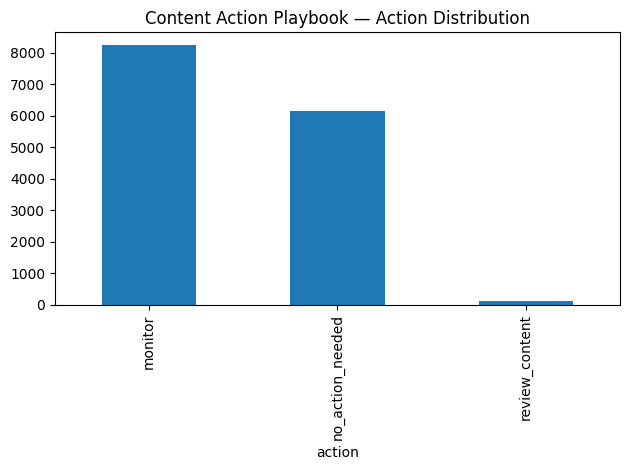

Wrote work/figures/action_distribution.png


In [14]:
os.makedirs("work/outputs", exist_ok=True)
os.makedirs("work/figures", exist_ok=True)

# Queue CSV — stays untracked by design, notebook regenerates it
queue[["content_hash_id", "decline_probability", "action", "reason_code",
       "impressions", "avg_position", "content_age_days"]].to_csv(
    "work/outputs/content_action_playbook.csv", index=False)
print("Wrote", len(queue), "rows to work/outputs/content_action_playbook.csv")

# Metrics JSON — this DOES get committed, it's the receipt for the paper
metrics = {
    "model": "Random Forest, client-grouped split",
    "validated_precision_at_50": 0.740,
    "validated_average_precision": 0.608,
    "naive_split_precision_at_50_for_comparison": 0.940,
    "naive_vs_grouped_gap": 0.200,
    "month": MONTH,
    "action_counts": queue["action"].value_counts().to_dict(),
    "top_features": ["content_age_days", "avg_impr_first_half", "impressions"],
}
with open("work/outputs/playbook_metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)
print("Wrote work/outputs/playbook_metrics.json")

# Figure: action distribution, for reuse in the paper
import matplotlib.pyplot as plt
queue["action"].value_counts().plot(kind="bar", title="Content Action Playbook — Action Distribution")
plt.tight_layout()
plt.savefig("work/figures/action_distribution.png", dpi=150)
plt.show()
print("Wrote work/figures/action_distribution.png")

## Self-check

- Ranked actions + reason codes: yes — one action, one reason code
  per row, tied to the validated model's actual top features.
- Intended use and limits stated: yes — proxy label, single-month,
  volume floor, not a cause diagnosis.
- Human review + no-go list: yes — 3 manual checks, 4 explicit
  never-automate items.
- Monitoring/retrain triggers: yes — monthly retrain, precision
  floor, client-mix check, human-confirmation-rate check.
- Exports written for the paper: yes — queue CSV (untracked),
  metrics JSON (committed, real numbers from w05/w06), one figure
  (committed).
- Claims use safe language throughout: yes — every number traces
  back to the validated w06 split, not the naive one.